In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

crime = pd.read_csv(r'C:\Users\LENOVO\Data Analysis\Python\Crime_Data_from_2020_to_Present.csv')
df = crime.copy()

# Cleaning and Preparing Data

In [122]:
df

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,modus_operandi,...,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,cross_street,latitude,longitude
0,10304468,2020-01-08,2020-01-08 22:30:00,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,0444 0913,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,2020-01-02,2020-01-01 03:30:00,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,0416 1822 1414,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,2020-04-14,2020-02-13 12:00:00,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,1501,...,AA,Adult Arrest,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,2020-01-01,2020-01-01 17:30:00,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329 1402,...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,2020-01-01,2020-01-01 04:15:00,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852945,231606525,2023-03-22,2023-03-22 10:00:00,16,Foothill,1602,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0411 1822,...,IC,Invest Cont,230.0,NaN,NaN,NaN,12800 FILMORE ST,NaN,34.2790,-118.4116
852946,231210064,2023-04-12,2023-04-12 16:30:00,12,77th Street,1239,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0601 0445 0416 0359,...,IC,Invest Cont,230.0,NaN,NaN,NaN,6100 S VERMONT AV,NaN,33.9841,-118.2915
852947,230115220,2023-07-02,2023-07-01 00:01:00,1,Central,154,1,352,PICKPOCKET,1822 0344,...,IC,Invest Cont,352.0,NaN,NaN,NaN,500 S MAIN ST,NaN,34.0467,-118.2485
852948,230906458,2023-03-05,2023-03-05 09:00:00,9,Van Nuys,914,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329 1822,...,IC,Invest Cont,745.0,NaN,NaN,NaN,14500 HARTLAND ST,NaN,34.1951,-118.4487


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852950 entries, 0 to 852949
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   division_number      852950 non-null  int64  
 1   date_reported        852950 non-null  object 
 2   date_occurred        852950 non-null  object 
 3   area                 852950 non-null  int64  
 4   area_name            852950 non-null  object 
 5   reporting_district   852950 non-null  int64  
 6   part                 852950 non-null  int64  
 7   crime_code           852950 non-null  int64  
 8   crime_description    852950 non-null  object 
 9   modus_operandi       734639 non-null  object 
 10  victim_age           852950 non-null  int64  
 11  victim_sex           740344 non-null  object 
 12  victim_descent       740336 non-null  object 
 13  premise_code         852940 non-null  float64
 14  premise_description  852432 non-null  object 
 15  weapon_code      

In [124]:
df.isna().sum()

division_number             0
date_reported               0
date_occurred               0
area                        0
area_name                   0
reporting_district          0
part                        0
crime_code                  0
crime_description           0
modus_operandi         118311
victim_age                  0
victim_sex             112606
victim_descent         112614
premise_code               10
premise_description       518
weapon_code            556202
weapon_description     556202
status                      0
status_description          0
crime_code_1               11
crime_code_2           790429
crime_code_3           850837
crime_code_4           852888
location                    0
cross_street           717289
latitude                    0
longitude                   0
dtype: int64

In [254]:
df["date_reported"] = pd.to_datetime(df["date_reported"], format = "%Y-%m-%d")

In [253]:
df["date_occurred"] = pd.to_datetime(df["date_occurred"], format="%Y-%m-%d %H:%M:%S")

In [127]:
df.columns

Index(['division_number', 'date_reported', 'date_occurred', 'area',
       'area_name', 'reporting_district', 'part', 'crime_code',
       'crime_description', 'modus_operandi', 'victim_age', 'victim_sex',
       'victim_descent', 'premise_code', 'premise_description', 'weapon_code',
       'weapon_description', 'status', 'status_description', 'crime_code_1',
       'crime_code_2', 'crime_code_3', 'crime_code_4', 'location',
       'cross_street', 'latitude', 'longitude'],
      dtype='object')

In [128]:
df = df.drop(labels = ["modus_operandi", "crime_code_2", "crime_code_3", "crime_code_4", "weapon_code", "weapon_description", "cross_street"], axis = 1)

In [129]:
df

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,victim_age,victim_sex,victim_descent,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude
0,10304468,2020-01-08,2020-01-08 22:30:00,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,36,F,B,501.0,SINGLE FAMILY DWELLING,AO,Adult Other,624.0,1100 W 39TH PL,34.0141,-118.2978
1,190101086,2020-01-02,2020-01-01 03:30:00,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,25,M,H,102.0,SIDEWALK,IC,Invest Cont,624.0,700 S HILL ST,34.0459,-118.2545
2,200110444,2020-04-14,2020-02-13 12:00:00,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,0,X,X,726.0,POLICE FACILITY,AA,Adult Arrest,845.0,200 E 6TH ST,34.0448,-118.2474
3,191501505,2020-01-01,2020-01-01 17:30:00,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),76,F,W,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,5400 CORTEEN PL,34.1685,-118.4019
4,191921269,2020-01-01,2020-01-01 04:15:00,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",31,X,X,409.0,BEAUTY SUPPLY STORE,IC,Invest Cont,740.0,14400 TITUS ST,34.2198,-118.4468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852945,231606525,2023-03-22,2023-03-22 10:00:00,16,Foothill,1602,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,102.0,SIDEWALK,IC,Invest Cont,230.0,12800 FILMORE ST,34.2790,-118.4116
852946,231210064,2023-04-12,2023-04-12 16:30:00,12,77th Street,1239,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,222.0,LAUNDROMAT,IC,Invest Cont,230.0,6100 S VERMONT AV,33.9841,-118.2915
852947,230115220,2023-07-02,2023-07-01 00:01:00,1,Central,154,1,352,PICKPOCKET,24,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,352.0,500 S MAIN ST,34.0467,-118.2485
852948,230906458,2023-03-05,2023-03-05 09:00:00,9,Van Nuys,914,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),53,F,H,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,14500 HARTLAND ST,34.1951,-118.4487


In [130]:
df.isna().sum()

division_number             0
date_reported               0
date_occurred               0
area                        0
area_name                   0
reporting_district          0
part                        0
crime_code                  0
crime_description           0
victim_age                  0
victim_sex             112606
victim_descent         112614
premise_code               10
premise_description       518
status                      0
status_description          0
crime_code_1               11
location                    0
latitude                    0
longitude                   0
dtype: int64

In [131]:
df.sort_values(by = "date_reported")

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,victim_age,victim_sex,victim_descent,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude
39025,201004026,2020-01-01,2020-01-01 18:23:00,10,West Valley,1091,1,310,BURGLARY,44,M,O,504.0,OTHER RESIDENCE,IC,Invest Cont,310.0,3800 WINFORD DR,34.1386,-118.5525
137157,202100503,2020-01-01,2020-01-01 13:15:00,21,Topanga,2189,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),75,M,X,402.0,MARKET,AA,Adult Arrest,343.0,20000 W VENTURA BL,34.1719,-118.5684
2389,200304056,2020-01-01,2020-01-01 14:37:00,3,Southwest,329,2,888,TRESPASSING,19,X,X,255.0,"AUTO DEALERSHIP (CHEVY, FORD, BMW, MERCEDES, E...",IC,Invest Cont,888.0,3300 S FIGUEROA ST,34.0225,-118.2796
103594,201804032,2020-01-01,2020-01-01 12:50:00,18,Southeast,1823,1,210,ROBBERY,50,M,B,102.0,SIDEWALK,IC,Invest Cont,210.0,CENTURY,33.9456,-118.2652
25891,200104434,2020-01-01,2020-01-01 02:50:00,1,Central,128,1,330,BURGLARY FROM VEHICLE,26,F,W,108.0,PARKING LOT,AO,Adult Other,330.0,300 E 2ND ST,34.0498,-118.2400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770235,230125557,2023-12-04,2023-12-04 06:50:00,1,Central,111,1,330,BURGLARY FROM VEHICLE,0,NaN,NaN,717.0,HEALTH SPA/GYM,IC,Invest Cont,330.0,700 W CESAR E CHAVEZ AV,34.0606,-118.2439
692345,231917421,2023-12-04,2023-12-03 09:45:00,19,Mission,1936,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,NaN,NaN,101.0,STREET,IC,Invest Cont,420.0,11400 AMBOY AV,34.2767,-118.4477
835683,232117291,2023-12-04,2023-03-01 12:00:00,21,Topanga,2125,2,354,THEFT OF IDENTITY,0,NaN,NaN,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,354.0,21400 SATICOY ST,34.2119,-118.6017
825607,231116467,2023-12-04,2023-12-01 22:30:00,11,Northeast,1141,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0,NaN,NaN,101.0,STREET,IC,Invest Cont,331.0,N KENMORE AV,34.1018,-118.2973


In [132]:
df.describe(include = ["float64", "int64"])

,division_number,area,reporting_district,part,crime_code,victim_age,premise_code,crime_code_1,latitude,longitude
count,8.529500e+05,852950.000000,852950.000000,852950.000000,852950.000000,852950.000000,852940.000000,852939.000000,852950.000000,852950.000000
mean,2.166969e+08,10.707354,1117.165490,1.412575,500.746338,29.742191,305.974292,500.486350,33.983232,-118.040106
std,1.100081e+07,6.097178,609.716073,0.492298,207.705242,21.799470,216.950442,207.493864,1.756263,6.089068
min,8.170000e+02,1.000000,101.000000,1.000000,110.000000,-3.000000,101.000000,110.000000,0.000000,-118.667600
25%,2.102184e+08,6.000000,615.000000,1.000000,331.000000,5.000000,101.000000,331.000000,34.014100,-118.429700
50%,2.202184e+08,11.000000,1141.000000,1.000000,442.000000,31.000000,203.000000,442.000000,34.058500,-118.321500
75%,2.301094e+08,16.000000,1617.000000,2.000000,626.000000,45.000000,501.000000,626.000000,34.163200,-118.273900
max,2.399306e+08,21.000000,2199.000000,2.000000,956.000000,120.000000,976.000000,956.000000,34.334300,0.000000


## The minimum victim age is -3 which is an error that'll be fixed

In [133]:
df["victim_age"].value_counts()

victim_age
 0      211842
 30      19421
 35      19008
 31      18603
 29      18552
         ...  
 97         63
-1          60
-2          13
 120         1
-3           1
Name: count, Length: 103, dtype: int64

### Removing all negative age values by selecting all values that are greater than 0

In [134]:
df = df[df["victim_age"] > 0]

In [135]:
df["victim_age"].value_counts()

victim_age
30     19421
35     19008
31     18603
29     18552
28     18266
       ...  
95        89
96        88
98        67
97        63
120        1
Name: count, Length: 99, dtype: int64

In [136]:
df.describe()

,division_number,date_reported,date_occurred,area,reporting_district,part,crime_code,victim_age,premise_code,crime_code_1,latitude,longitude
count,6.410340e+05,641034,641034,641034.000000,641034.000000,641034.000000,641034.000000,641034.000000,641033.000000,641028.000000,641034.000000,641034.000000
mean,2.165926e+08,2022-01-14 16:05:50.703394304,2022-01-03 05:49:01.566656768,10.693281,1115.722637,1.485054,499.540843,39.574642,334.613580,499.221184,33.984644,-118.041639
min,1.030447e+07,2020-01-01 00:00:00,2020-01-01 00:01:00,1.000000,101.000000,1.000000,110.000000,2.000000,101.000000,110.000000,0.000000,-118.667600
25%,2.102166e+08,2021-02-08 00:00:00,2021-01-23 05:00:00,5.000000,587.000000,1.000000,330.000000,28.000000,104.000000,330.000000,34.014600,-118.433000
50%,2.202116e+08,2022-02-07 00:00:00,2022-01-24 00:01:00,11.000000,1135.000000,1.000000,440.000000,37.000000,404.000000,440.000000,34.058700,-118.324400
75%,2.221162e+08,2022-12-28 00:00:00,2022-12-14 08:00:00,16.000000,1623.000000,2.000000,626.000000,50.000000,502.000000,626.000000,34.164900,-118.274900
max,2.399097e+08,2023-12-04 00:00:00,2023-12-04 10:30:00,21.000000,2199.000000,2.000000,956.000000,120.000000,976.000000,956.000000,34.334300,0.000000
std,1.094125e+07,NaN,NaN,6.162445,615.983228,0.499777,222.237785,15.594740,216.701156,221.991404,1.758465,6.096776


In [137]:
df["Year"] = df["date_occurred"].dt.year
df["Month"] = df["date_occurred"].dt.month

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25840\2007559968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["date_occurred"].dt.year
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25840\2007559968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["date_occurred"].dt.month


In [138]:
df.sort_values(by = "date_occurred")

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,victim_age,...,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude,Year,Month
1559,210708670,2021-05-11,2020-01-01 00:01:00,7,Wilshire,775,2,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,13,...,710.0,OTHER PREMISE,AO,Adult Other,812.0,1700 S LONGWOOD AV,34.0437,-118.3440,2020,1
199127,230711357,2023-06-26,2020-01-01 00:01:00,7,Wilshire,774,2,354,THEFT OF IDENTITY,32,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,354.0,4900 W WASHINGTON BL,34.0431,-118.3482,2020,1
142451,211420180,2021-10-19,2020-01-01 00:01:00,14,Pacific,1474,2,940,EXTORTION,17,...,722.0,COLLEGE/JUNIOR COLLEGE/UNIVERSITY,IC,Invest Cont,940.0,00 LMU DR,33.9666,-118.4236,2020,1
13541,221611597,2022-08-19,2020-01-01 00:01:00,16,Foothill,1643,2,354,THEFT OF IDENTITY,22,...,406.0,OTHER STORE,IC,Invest Cont,354.0,10200 TELFAIR AV,34.2554,-118.4169,2020,1
199412,231818830,2023-11-01,2020-01-01 00:01:00,18,Southeast,1841,2,762,LEWD CONDUCT,6,...,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,762.0,500 W 108TH ST,33.9383,-118.2826,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697584,230618559,2023-12-04,2023-12-04 07:30:00,6,Hollywood,668,2,756,WEAPONS POSSESSION/BOMBING,57,...,102.0,SIDEWALK,IC,Invest Cont,756.0,ST ANDREWS,34.0968,-118.3110,2023,12
805632,231224245,2023-12-04,2023-12-04 08:00:00,12,77th Street,1218,2,901,VIOLATION OF RESTRAINING ORDER,39,...,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,901.0,900 W 55TH ST,33.9923,-118.2897,2023,12
684845,230717943,2023-12-04,2023-12-04 09:00:00,7,Wilshire,765,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",54,...,102.0,SIDEWALK,IC,Invest Cont,230.0,LA BREA,34.0479,-118.3447,2023,12
780115,230717933,2023-12-04,2023-12-04 09:00:00,7,Wilshire,784,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",39,...,101.0,STREET,IC,Invest Cont,230.0,LA BREA,34.0385,-118.3485,2023,12


### We can see that the data goes till Dec 4th of 2023, so we can exclude Dec 2023 to achieve better results

In [139]:
df = df[~((df["Month"] == 12) & (df["Year"] == 2023))]
df.sort_values(by = "date_occurred")

,division_number,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,victim_age,...,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude,Year,Month
198873,231210407,2023-04-18,2020-01-01 00:01:00,12,77th Street,1259,2,354,THEFT OF IDENTITY,59,...,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,354.0,700 E 73RD ST,33.9739,-118.2630,2020,1
148603,201225633,2020-10-21,2020-01-01 00:01:00,12,77th Street,1204,1,815,SEXUAL PENETRATION W/FOREIGN OBJECT,4,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",AO,Adult Other,812.0,1400 W VERNON AV,34.0037,-118.3007,2020,1
49840,200807697,2020-03-25,2020-01-01 00:01:00,8,West LA,827,2,956,"LETTERS, LEWD - TELEPHONE CALLS, LEWD",13,...,501.0,SINGLE FAMILY DWELLING,AA,Adult Arrest,956.0,500 LORNA LN,34.0557,-118.4685,2020,1
99304,200411625,2020-08-10,2020-01-01 00:01:00,4,Hollenbeck,429,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,28,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",AO,Adult Other,626.0,3700 LOWELL AV,34.0882,-118.1624,2020,1
2400,200304092,2020-01-01,2020-01-01 00:01:00,3,Southwest,312,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",34,...,101.0,STREET,IC,Invest Cont,740.0,2700 S MANSFIELD AV,34.0308,-118.3529,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745666,231421194,2023-11-30,2023-11-30 23:35:00,14,Pacific,1488,2,624,BATTERY - SIMPLE ASSAULT,27,...,101.0,STREET,IC,Invest Cont,624.0,CENTURY BL,33.9456,-118.3860,2023,11
676311,230516383,2023-11-30,2023-11-30 23:40:00,5,Harbor,507,1,440,THEFT PLAIN - PETTY ($950 & UNDER),13,...,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,440.0,1500 W 228TH ST,33.8190,-118.3037,2023,11
699356,231518412,2023-12-02,2023-11-30 23:44:00,15,N Hollywood,1557,1,330,BURGLARY FROM VEHICLE,42,...,101.0,STREET,IC,Invest Cont,330.0,4800 CRANER AV,34.1577,-118.3691,2023,11
672120,230717815,2023-12-01,2023-11-30 23:45:00,7,Wilshire,702,1,310,BURGLARY,30,...,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,310.0,700 N VISTA ST,34.0836,-118.3523,2023,11


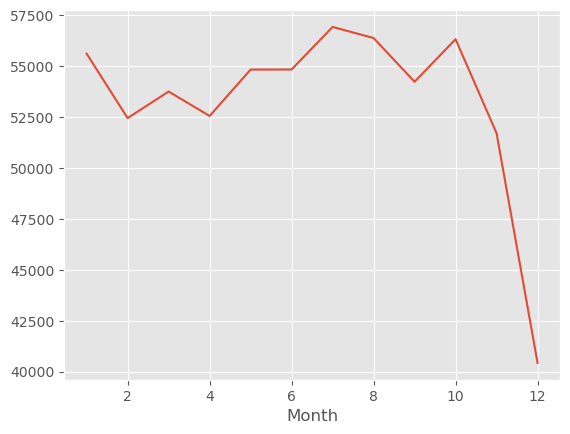

In [140]:
monthly_crime_rate = df["Month"].value_counts().sort_index().plot()

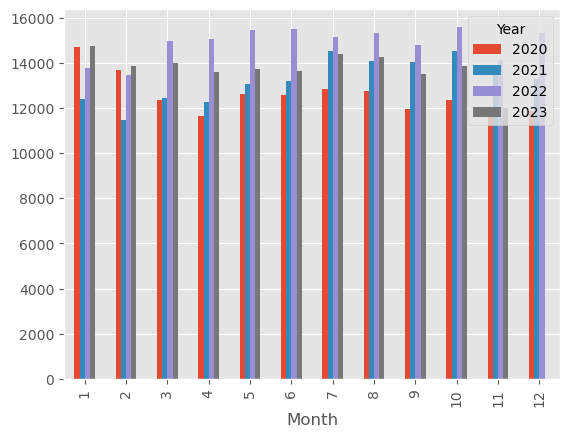

In [141]:
yearly_crime_rate = df.groupby(["Month", "Year"]).size().unstack().plot(kind = "bar" )

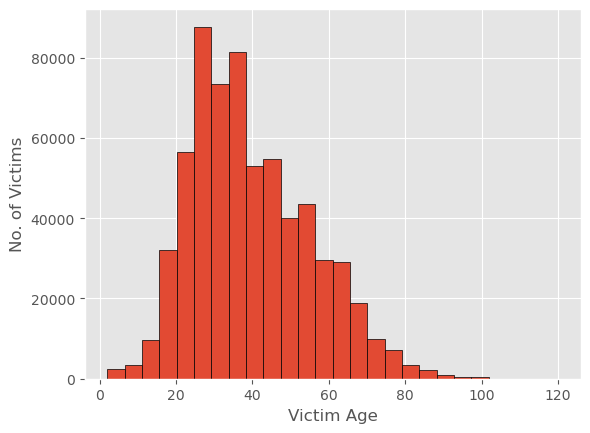

In [142]:
plt.hist(df["victim_age"], edgecolor= "black", bins = 26)
plt.xlabel("Victim Age")
plt.ylabel("No. of Victims")
plt.show()

In [143]:
df["time_occurred"] = df["date_occurred"].dt.time
df["date_occurred"] = df["date_occurred"].dt.date

In [144]:
df.columns

Index(['division_number', 'date_reported', 'date_occurred', 'area',
       'area_name', 'reporting_district', 'part', 'crime_code',
       'crime_description', 'victim_age', 'victim_sex', 'victim_descent',
       'premise_code', 'premise_description', 'status', 'status_description',
       'crime_code_1', 'location', 'latitude', 'longitude', 'Year', 'Month',
       'time_occurred'],
      dtype='object')

# Reorder the columns

In [145]:
cols = ['division_number', 'Year', 'Month', 'date_reported', 'date_occurred','time_occurred', 'area',
       'area_name', 'reporting_district', 'part', 'crime_code',
       'crime_description', 'victim_age', 'victim_sex', 'victim_descent',
       'premise_code', 'premise_description', 'status', 'status_description',
       'crime_code_1', 'location', 'latitude', 'longitude']
df = df[cols]

In [146]:
df

,division_number,Year,Month,date_reported,date_occurred,time_occurred,area,area_name,reporting_district,part,...,victim_sex,victim_descent,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude
0,10304468,2020,1,2020-01-08,2020-01-08,22:30:00,3,Southwest,377,2,...,F,B,501.0,SINGLE FAMILY DWELLING,AO,Adult Other,624.0,1100 W 39TH PL,34.0141,-118.2978
1,190101086,2020,1,2020-01-02,2020-01-01,03:30:00,1,Central,163,2,...,M,H,102.0,SIDEWALK,IC,Invest Cont,624.0,700 S HILL ST,34.0459,-118.2545
3,191501505,2020,1,2020-01-01,2020-01-01,17:30:00,15,N Hollywood,1543,2,...,F,W,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,5400 CORTEEN PL,34.1685,-118.4019
4,191921269,2020,1,2020-01-01,2020-01-01,04:15:00,19,Mission,1998,2,...,X,X,409.0,BEAUTY SUPPLY STORE,IC,Invest Cont,740.0,14400 TITUS ST,34.2198,-118.4468
5,200100501,2020,1,2020-01-02,2020-01-01,00:30:00,1,Central,163,1,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,121.0,700 S BROADWAY,34.0452,-118.2534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852945,231606525,2023,3,2023-03-22,2023-03-22,10:00:00,16,Foothill,1602,1,...,F,H,102.0,SIDEWALK,IC,Invest Cont,230.0,12800 FILMORE ST,34.2790,-118.4116
852946,231210064,2023,4,2023-04-12,2023-04-12,16:30:00,12,77th Street,1239,1,...,M,B,222.0,LAUNDROMAT,IC,Invest Cont,230.0,6100 S VERMONT AV,33.9841,-118.2915
852947,230115220,2023,7,2023-07-02,2023-07-01,00:01:00,1,Central,154,1,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,352.0,500 S MAIN ST,34.0467,-118.2485
852948,230906458,2023,3,2023-03-05,2023-03-05,09:00:00,9,Van Nuys,914,2,...,F,H,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,14500 HARTLAND ST,34.1951,-118.4487


In [147]:
crimes_per_day = df.groupby(["date_occurred", "crime_description"]).size()
crimes_per_day

date_occurred  crime_description                                      
2020-01-01     ARSON                                                       3
               ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT             47
               ATTEMPTED ROBBERY                                           5
               BATTERY - SIMPLE ASSAULT                                   73
               BATTERY POLICE (SIMPLE)                                     1
                                                                          ..
2023-11-30     VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)    18
               VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    8
               VEHICLE - ATTEMPT STOLEN                                    3
               VIOLATION OF COURT ORDER                                    2
               VIOLATION OF RESTRAINING ORDER                              6
Length: 69423, dtype: int64

In [148]:
top_20_crimes = crimes_per_day.groupby("crime_description").mean().reset_index(name = "daily_avg").sort_values(by = "daily_avg").tail(20)

In [149]:
top_20_crimes

,crime_description,daily_avg
11,BIKE - STOLEN,4.889522
102,SHOPLIFTING - PETTY THEFT ($950 & UNDER),4.945848
125,TRESPASSING,5.189170
133,VIOLATION OF RESTRAINING ORDER,7.362999
70,INTIMATE PARTNER - AGGRAVATED ASSAULT,8.050385
14,BRANDISH WEAPON,9.025874
111,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),10.067832
37,CRIMINAL THREATS - NO WEAPON DISPLAYED,11.883217
128,VANDALISM - MISDEAMEANOR ($399 OR UNDER),12.521678
120,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",15.716783


Text(0.5, 0, 'Type of Crime')

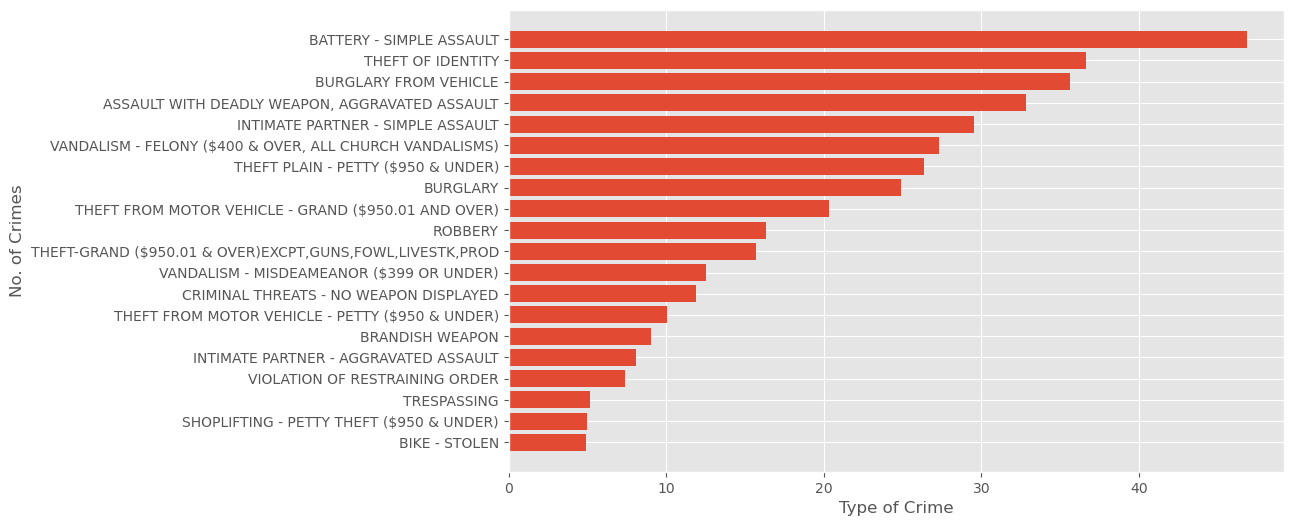

In [150]:
plt.figure( figsize = (10,6))
plt.barh(top_20_crimes["crime_description"], top_20_crimes["daily_avg"])
plt.ylabel("No. of Crimes")
plt.xlabel("Type of Crime")

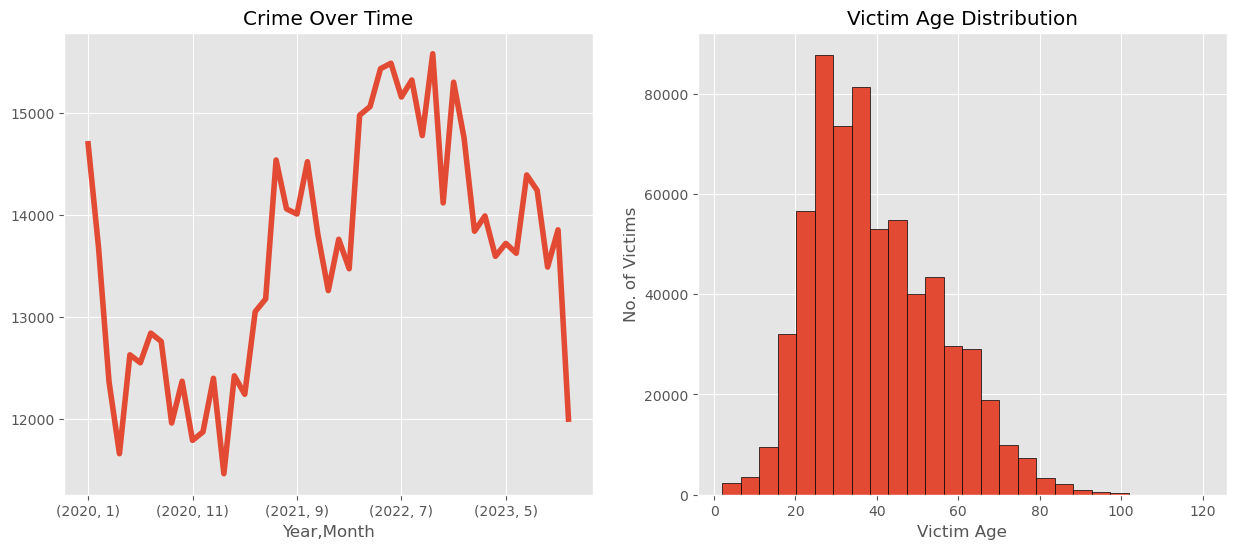

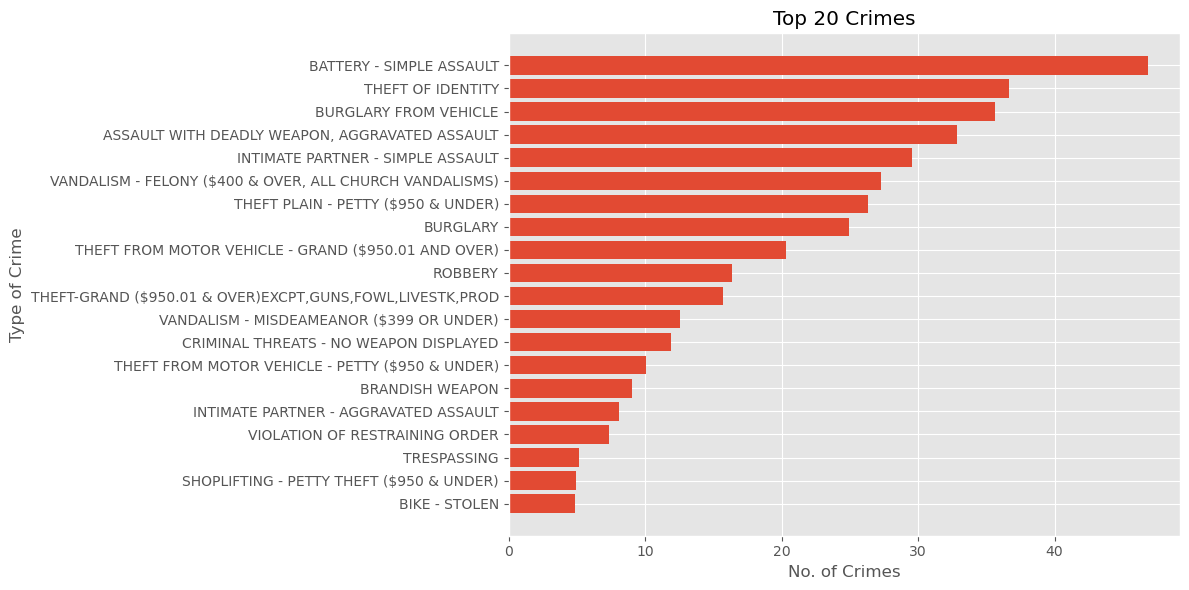

In [151]:
plt.style.use("ggplot")
plt.figure( figsize = (15,6))

plt.subplot(1,2,1)
df.groupby([ "Year", "Month"]).size().plot(linewidth = 4).set_title("Crime Over Time")

plt.subplot(1,2,2)
plt.hist(df["victim_age"], edgecolor= "black", bins = 26)
plt.xlabel("Victim Age")
plt.ylabel("No. of Victims")
plt.title("Victim Age Distribution")


plt.figure( figsize = (12,6))
plt.barh(top_20_crimes["crime_description"], top_20_crimes["daily_avg"])
plt.xlabel("No. of Crimes")
plt.ylabel("Type of Crime")
plt.title("Top 20 Crimes")

plt.tight_layout()
plt.show()

In [152]:
df

,division_number,Year,Month,date_reported,date_occurred,time_occurred,area,area_name,reporting_district,part,...,victim_sex,victim_descent,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude
0,10304468,2020,1,2020-01-08,2020-01-08,22:30:00,3,Southwest,377,2,...,F,B,501.0,SINGLE FAMILY DWELLING,AO,Adult Other,624.0,1100 W 39TH PL,34.0141,-118.2978
1,190101086,2020,1,2020-01-02,2020-01-01,03:30:00,1,Central,163,2,...,M,H,102.0,SIDEWALK,IC,Invest Cont,624.0,700 S HILL ST,34.0459,-118.2545
3,191501505,2020,1,2020-01-01,2020-01-01,17:30:00,15,N Hollywood,1543,2,...,F,W,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,5400 CORTEEN PL,34.1685,-118.4019
4,191921269,2020,1,2020-01-01,2020-01-01,04:15:00,19,Mission,1998,2,...,X,X,409.0,BEAUTY SUPPLY STORE,IC,Invest Cont,740.0,14400 TITUS ST,34.2198,-118.4468
5,200100501,2020,1,2020-01-02,2020-01-01,00:30:00,1,Central,163,1,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,121.0,700 S BROADWAY,34.0452,-118.2534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852945,231606525,2023,3,2023-03-22,2023-03-22,10:00:00,16,Foothill,1602,1,...,F,H,102.0,SIDEWALK,IC,Invest Cont,230.0,12800 FILMORE ST,34.2790,-118.4116
852946,231210064,2023,4,2023-04-12,2023-04-12,16:30:00,12,77th Street,1239,1,...,M,B,222.0,LAUNDROMAT,IC,Invest Cont,230.0,6100 S VERMONT AV,33.9841,-118.2915
852947,230115220,2023,7,2023-07-02,2023-07-01,00:01:00,1,Central,154,1,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,352.0,500 S MAIN ST,34.0467,-118.2485
852948,230906458,2023,3,2023-03-05,2023-03-05,09:00:00,9,Van Nuys,914,2,...,F,H,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,14500 HARTLAND ST,34.1951,-118.4487


In [193]:
df["date_reported"] = pd.to_datetime(df["date_reported"])
df["date_occurred"] = pd.to_datetime(df["date_occurred"])

# Now the subtraction will work
df["reported_after"] = df["date_reported"] - df["date_occurred"]
df["date_reported"] = pd.to_datetime(df["date_reported"])

df["reported_after"]

0        0 days
1        1 days
3        0 days
4        0 days
5        1 days
          ...  
852945   0 days
852946   0 days
852947   1 days
852948   0 days
852949   1 days
Name: reported_after, Length: 640111, dtype: timedelta64[ns]

In [159]:
cols = ['division_number', 'Year', 'Month', 'date_reported', 'date_occurred',
       'time_occurred', 'reported_after', 'area', 'area_name', 'reporting_district', 'part',
       'crime_code', 'crime_description', 'victim_age', 'victim_sex',
       'victim_descent', 'premise_code', 'premise_description', 'status',
       'status_description', 'crime_code_1', 'location', 'latitude', 'longitude']
df = df[cols]
df


,division_number,Year,Month,date_reported,date_occurred,time_occurred,reported_after,area,area_name,reporting_district,...,victim_sex,victim_descent,premise_code,premise_description,status,status_description,crime_code_1,location,latitude,longitude
0,10304468,2020,1,2020-01-08,2020-01-08,22:30:00,0 days,3,Southwest,377,...,F,B,501.0,SINGLE FAMILY DWELLING,AO,Adult Other,624.0,1100 W 39TH PL,34.0141,-118.2978
1,190101086,2020,1,2020-01-02,2020-01-01,03:30:00,1 days,1,Central,163,...,M,H,102.0,SIDEWALK,IC,Invest Cont,624.0,700 S HILL ST,34.0459,-118.2545
3,191501505,2020,1,2020-01-01,2020-01-01,17:30:00,0 days,15,N Hollywood,1543,...,F,W,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,5400 CORTEEN PL,34.1685,-118.4019
4,191921269,2020,1,2020-01-01,2020-01-01,04:15:00,0 days,19,Mission,1998,...,X,X,409.0,BEAUTY SUPPLY STORE,IC,Invest Cont,740.0,14400 TITUS ST,34.2198,-118.4468
5,200100501,2020,1,2020-01-02,2020-01-01,00:30:00,1 days,1,Central,163,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,121.0,700 S BROADWAY,34.0452,-118.2534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852945,231606525,2023,3,2023-03-22,2023-03-22,10:00:00,0 days,16,Foothill,1602,...,F,H,102.0,SIDEWALK,IC,Invest Cont,230.0,12800 FILMORE ST,34.2790,-118.4116
852946,231210064,2023,4,2023-04-12,2023-04-12,16:30:00,0 days,12,77th Street,1239,...,M,B,222.0,LAUNDROMAT,IC,Invest Cont,230.0,6100 S VERMONT AV,33.9841,-118.2915
852947,230115220,2023,7,2023-07-02,2023-07-01,00:01:00,1 days,1,Central,154,...,F,H,735.0,NIGHT CLUB (OPEN EVENINGS ONLY),IC,Invest Cont,352.0,500 S MAIN ST,34.0467,-118.2485
852948,230906458,2023,3,2023-03-05,2023-03-05,09:00:00,0 days,9,Van Nuys,914,...,F,H,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",IC,Invest Cont,745.0,14500 HARTLAND ST,34.1951,-118.4487


In [194]:
df["reported_after"] = df["reported_after"].dt.days

In [198]:
avg_reporting_time = df.groupby("crime_description")["reported_after"].mean().reset_index()

In [199]:
avg_reporting_time = avg_reporting_time.rename(columns = {"reported_after" : "Average Reporting Time"})

In [217]:
avg_reporting_time = avg_reporting_time.sort_values(by = "Average Reporting Time")
avg_reporting_time

,crime_description,Average Reporting Time
61,FIREARMS RESTRAINING ORDER (FIREARMS RO),0.000000
77,LYNCHING,0.000000
85,PETTY THEFT - AUTO REPAIR,0.000000
91,PURSE SNATCHING - ATTEMPT,0.083333
46,DISRUPT SCHOOL,0.111111
...,...,...
76,LEWD/LASCIVIOUS ACTS WITH CHILD,102.657534
99,"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...",110.480728
9,BIGAMY,116.500000
98,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,121.471014


In [220]:
fastest_10_reports = avg_reporting_time.head(10)

<BarContainer object of 10 artists>

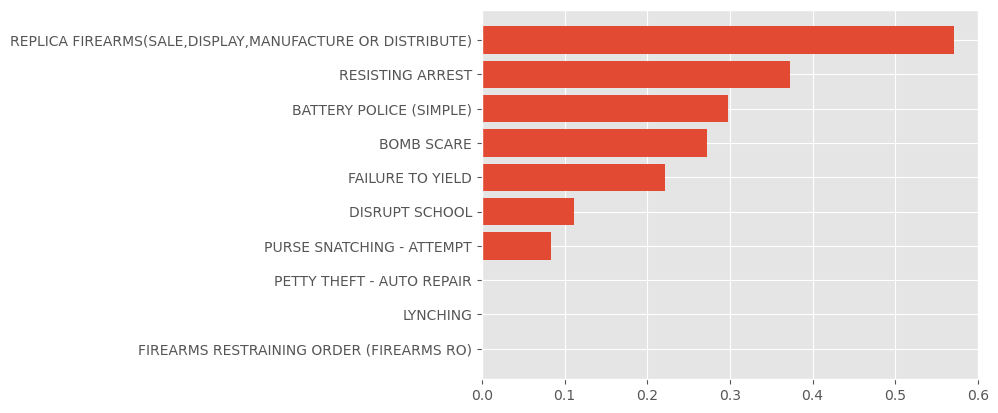

In [221]:
plt.barh(fastest_10_reports["crime_description"], fastest_10_reports["Average Reporting Time"])
#plt.xticks(rotation = 90)

In [232]:
top3_vic_age = df.groupby("crime_description")["victim_age"].mean().reset_index().sort_values(by = "victim_age",ascending=False).head(3)

In [233]:
top3_vic_age

,crime_description,victim_age
45,DISHONEST EMPLOYEE ATTEMPTED THEFT,60.000000
12,BLOCKING DOOR INDUCTION CENTER,54.666667
77,LYNCHING,53.000000


In [245]:
crimes_at_night = df[(df["date_occurred"].dt.hour >= 20) | (df["date_occurred"].dt.hour <= 4)]
crimes_at_night["area_name"].value_counts()

area_name
Central        45331
77th Street    40777
Southwest      40388
Pacific        35976
Hollywood      34113
Southeast      32542
Olympic        31511
Wilshire       30836
N Hollywood    30822
Newton         29894
Topanga        29661
Rampart        29276
West LA        29251
Van Nuys       28902
West Valley    26750
Mission        26099
Northeast      25738
Devonshire     24920
Harbor         24210
Hollenbeck     21581
Foothill       21533
Name: count, dtype: int64

In [264]:
hourly_crime = df["date_occurred"].dt.hour.value_counts().sort_index().reset_index()
hourly_crime

,date_occurred,count
0,0,35109
1,1,25806
2,2,21859
3,3,19085
4,4,16123
5,5,14868
6,6,19549
7,7,22031
8,8,31474
9,9,30864


In [267]:
df[df["date_occurred"].dt.hour == 12]["crime_description"].value_counts()

crime_description
THEFT OF IDENTITY                               9103
VEHICLE - STOLEN                                4054
BATTERY - SIMPLE ASSAULT                        3962
THEFT PLAIN - PETTY ($950 & UNDER)              3790
BURGLARY                                        2946
                                                ... 
DRUGS, TO A MINOR                                  1
THEFT, COIN MACHINE - GRAND ($950.01 & OVER)       1
BIGAMY                                             1
GRAND THEFT / INSURANCE FRAUD                      1
INCITING A RIOT                                    1
Name: count, Length: 124, dtype: int64

In [270]:
no_id_theft = df[~(df["crime_description"] == "THEFT OF IDENTITY")]

In [277]:
hourly_crime = no_id_theft["date_occurred"].dt.hour.value_counts().sort_index().reset_index()

In [278]:
hourly_crime


,date_occurred,count
0,0,29448
1,1,24308
2,2,21152
3,3,18545
4,4,15694
5,5,14247
6,6,16193
7,7,19885
8,8,27810
9,9,27800


<BarContainer object of 24 artists>

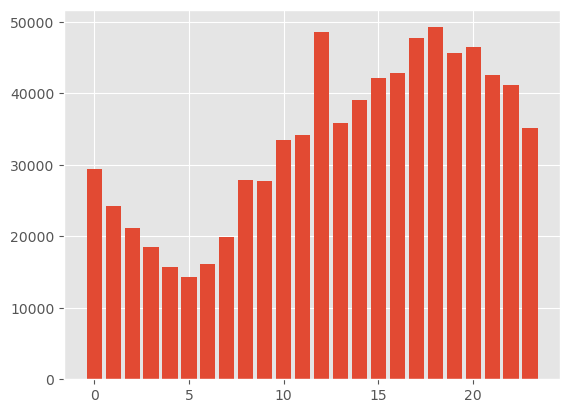

In [279]:
plt.bar(hourly_crime.index, hourly_crime["count"])